**Importing necessary libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense, Dropout, Bidirectional, Flatten,
    Conv1D, Reshape, Lambda, BatchNormalization, SpatialDropout1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score
import re
import nltk
import tensorflow as tf
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import matplotlib
import seaborn as sns
import sklearn
import keras

print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"NLTK Version: {nltk.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"Seaborn Version: {sns.__version__}")

3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
NumPy Version: 1.26.4
Pandas Version: 2.2.2
Matplotlib Version: 3.10.0
TensorFlow Version: 2.18.0
NLTK Version: 3.9.1
Scikit-learn Version: 1.6.1
Keras Version: 3.8.0
Seaborn Version: 0.13.2


In [ ]:
!python --version

Python 3.11.11


**Loading and exploration of datasets**

In [ ]:
train_file = '/content/drive/MyDrive/text_data/train_dataset.csv'  # Update the file paths
test_file = '/content/drive/MyDrive/text_data/test_dataset.csv'
eval_file = '/content/drive/MyDrive/text_data/evaluation_dataset.csv'

train_data = pd.read_csv(train_file)
test_data = pd.read_csv(test_file)
eval_data = pd.read_csv(eval_file)

print("Training Dataset Overview:")
print(train_data.head())
print("\nTesting Dataset Overview:")
print(test_data.head())
print("\nEvaluation Dataset Overview:")
print(eval_data.head())

print("Training Dataset Shape:")
print(train_data.shape)
print("\nTesting Dataset Shape:")
print(test_data.shape)
print("\nEvaluation Dataset Shape:")
print(eval_data.shape)

Training Dataset Overview:
                                                text  generated
0  Students would benefit from this a lot because...          0
1  Dear Florida senator, we should keep the Elect...          0
2  Dear Senator,\n\nIt is my belief that there is...          0
3  Dear TEACHER_NAME (Principal) ,\n\nI think tha...          0
4  Stop arguing with me Bob, I know I'm right abo...          0

Testing Dataset Overview:
                                                text  generated
0  Dear TEACHER_NAME,\n\nHello, my name is STUDEN...          0
1  The Seagoing Cowboys program is the best aroun...          0
2  Cars. Mostly everyone has been in a car, had a...          0
3  Schools should allow distance learning as an a...          0
4  Dear principle,\n\nI am currently a student at...          0

Evaluation Dataset Overview:
                                                text  generated
0  Your principal has decided all students must p...          0
1  When you're tryin

<ipython-input-16-188287e33171>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Dataset', y='Size', data=dataset_sizes, palette=['#E63946', '#457B9D', '#2A9D8F'])  # Custom color codes


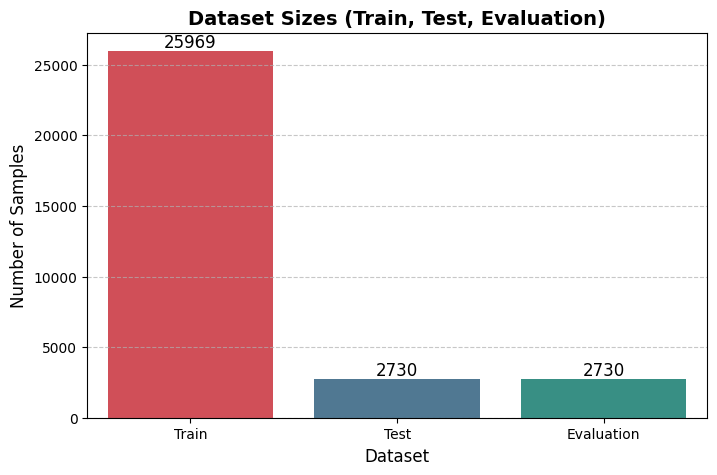

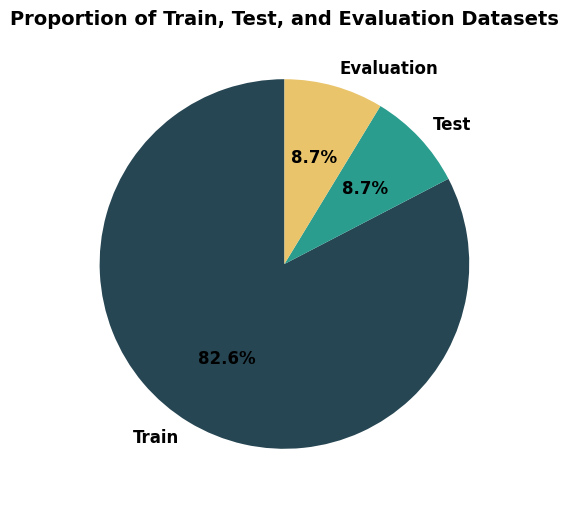

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for visualization
dataset_sizes = pd.DataFrame({
    'Dataset': ['Train', 'Test', 'Evaluation'],
    'Size': [len(train_data), len(test_data), len(eval_data)]
})

# Bar plot with a new color palette
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Dataset', y='Size', data=dataset_sizes, palette=['#E63946', '#457B9D', '#2A9D8F'])  # Custom color codes

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title('Dataset Sizes (Train, Test, Evaluation)', fontsize=14, fontweight='bold')
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid for better readability
plt.show()

# Pie chart with a new set of colors
plt.figure(figsize=(6, 6))
plt.pie(dataset_sizes['Size'], labels=dataset_sizes['Dataset'], autopct='%1.1f%%',
colors=['#264653', '#2A9D8F', '#E9C46A']
,  # Alternative color scheme
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Proportion of Train, Test, and Evaluation Datasets', fontsize=14, fontweight='bold')
plt.show()


**Preprocessing and Feature extraction**

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

train_data['cleaned_text'] = train_data['text'].apply(preprocess_text)
test_data['cleaned_text'] = test_data['text'].apply(preprocess_text)
eval_data['cleaned_text'] = eval_data['text'].apply(preprocess_text)

X_train = train_data['cleaned_text']
y_train = train_data['generated']
X_test = test_data['cleaned_text']
y_test = test_data['generated']
X_eval = eval_data['cleaned_text']
y_eval = eval_data['generated']

**Tokenization and Padding**

In [ ]:
MAX_NUM_WORDS = 20000
MAX_SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_eval_seq = tokenizer.texts_to_sequences(X_eval)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_eval_pad = pad_sequences(X_eval_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

vocab_size = min(len(tokenizer.word_index) + 1, MAX_NUM_WORDS)
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)
y_eval = to_categorical(y_eval, num_classes=2)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, Dense, Dropout, Flatten, LayerNormalization,
                                     Conv1D, Reshape, Lambda, MultiHeadAttention, Bidirectional, LSTM,
                                     GlobalAveragePooling1D, DepthwiseConv2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K


# **Build Lightweight BiLSTM + Attention Model**
def build_rnn_model():
    input_layer = Input(shape=(MAX_SEQUENCE_LENGTH,))
    embedding = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(input_layer)

    # **Lightweight BiLSTM**
    lstm = Bidirectional(LSTM(16, return_sequences=True, recurrent_dropout=0.2))(embedding)

    # **Lightweight Attention (Single Head, Smaller Key Dimension)**
    attention_output = MultiHeadAttention(num_heads=1, key_dim=8)(lstm, lstm)
    lstm = attention_output + lstm  # **Residual Connection**
    lstm = LayerNormalization()(lstm)

    # **Additional LSTM Layer (Smaller Size)**
    lstm = Bidirectional(LSTM(8, recurrent_dropout=0.2))(lstm)
    lstm = Dropout(0.2)(lstm)

    # **Fully Connected Output Layer**
    dense = Dense(8, activation='swish', kernel_regularizer=l2(0.002))(lstm)
    output = Dense(2, activation='softmax')(dense)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='categorical_crossentropy', metrics=['accuracy'])

    return model




In [ ]:
print("Summary of Attention-based BiLSTM")
rnn_model = build_rnn_model()
rnn_model.summary()


Summary of Attention-based BiLSTM


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 300)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_5 (Embedding)   │ (None, 300, 100)       │      2,000,000 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_4           │ (None, 300, 32)        │         14,976 │ embedding_5[0][0]      │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_2    │ (None, 300, 32)        │          1,080 │ bidirectional_4[0][0], │
│ (MultiHeadAttention)      │                        │                │ bidirectional_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 300, 32)        │              0 │ multi_head_attention_… │
│                           │                        │                │ bidirectional_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_4     │ (None, 300, 32)        │             64 │ add_2[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_5           │ (None, 16)             │          2,624 │ layer_normalization_4… │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 16)             │              0 │ bidirectional_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 8)              │            136 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 2)              │             18 │ dense_10[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,018,898 (7.70 MB)

 Trainable params: 2,018,898 (7.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, Reshape, Dense, Dropout, Lambda, Flatten, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

# Squash function for Capsule Network
def squash(x, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(x), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm + tf.keras.backend.epsilon()) / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())
    return x * scale

# Build Efficient-CapsNet model
def build_efficient_capsnet():


    input_layer = Input(shape=(MAX_SEQUENCE_LENGTH,))

    # Embedding Layer
    embedding = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(input_layer)

    # Convolutional Feature Extractor
    conv = Conv1D(128, 5, activation='swish', padding='same')(embedding)
    conv = LayerNormalization()(conv)
    conv = Dropout(0.3)(conv)

    # Primary Capsules
    primary_caps = Conv1D(32, 5, strides=2, activation='swish', padding='same')(conv)
    primary_caps = Reshape((-1, 8))(primary_caps)
    primary_caps = Lambda(squash)(primary_caps)

    # Capsule Fully Connected Layer
    digit_caps = Dense(16, activation='swish', kernel_regularizer=l2(0.005))(Flatten()(primary_caps))

    # Output Layer (Binary Classification: Real vs Fake)
    output = Dense(2, activation='softmax')(digit_caps)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer=AdamW(learning_rate=0.0003), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

efficient_capsnet = build_efficient_capsnet()
efficient_capsnet.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_6 (Embedding)              │ (None, 300, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 300, 128)            │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_5                │ (None, 300, 128)            │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 300, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 150, 32)             │          20,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 600, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 600, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4800)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 16)                  │          76,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,161,746 (8.25 MB)

 Trainable params: 2,161,746 (8.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, GRU, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define the GRU + CNN Model
def build_gru_cnn_model(vocab_size, embedding_dim, max_seq_length):
    input_layer = Input(shape=(max_seq_length,))

    # Embedding Layer
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_seq_length)(input_layer)

    # GRU Layer (Lighter than LSTM)
    gru_layer = GRU(64, return_sequences=True)(embedding_layer)

    # CNN Layer
    cnn_layer = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(gru_layer)

    # Global Max Pooling
    pooling_layer = GlobalMaxPooling1D()(cnn_layer)

    # Fully Connected Layer
    dense_layer = Dense(32, activation='relu')(pooling_layer)
    dropout_layer = Dropout(0.3)(dense_layer)

    # Output Layer
    output_layer = Dense(2, activation='softmax')(dropout_layer)

    # Compile Model
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Initialize model
gru_cnn = build_gru_cnn_model(vocab_size=vocab_size, embedding_dim=EMBEDDING_DIM, max_seq_length=MAX_SEQUENCE_LENGTH)

# Model Summary
gru_cnn.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_7 (Embedding)              │ (None, 300, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 300, 64)             │          31,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 300, 64)             │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,046,370 (7.81 MB)

 Trainable params: 2,046,370 (7.81 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training Efficient-CapsNet...
Epoch 1/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8847 - loss: 0.3238

812/812 ━━━━━━━━━━━━━━━━━━━━ 166s 199ms/step - accuracy: 0.8848 - loss: 0.3236 - val_accuracy: 0.9824 - val_loss: 0.0724
Epoch 2/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9943 - loss: 0.0370

812/812 ━━━━━━━━━━━━━━━━━━━━ 179s 172ms/step - accuracy: 0.9943 - loss: 0.0370 - val_accuracy: 0.9846 - val_loss: 0.0579
Epoch 3/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9962 - loss: 0.0226

812/812 ━━━━━━━━━━━━━━━━━━━━ 140s 169ms/step - accuracy: 0.9962 - loss: 0.0226 - val_accuracy: 0.9883 - val_loss: 0.0561
Epoch 4/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 134s 166ms/step - accuracy: 0.9983 - loss: 0.0140 - val_accuracy: 0.9857 - val_loss: 0.0651
Epoch 5/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9990 - loss: 0.0110

812/812 ━━━━━━━━━━━━━━━━━━━━ 144s 168ms/step - accuracy: 0.9990 - loss: 0.0110 - val_accuracy: 0.9886 - val_loss: 0.0547
Epoch 6/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 141s 174ms/step - accuracy: 0.9986 - loss: 0.0109 - val_accuracy: 0.9868 - val_loss: 0.0610
Epoch 7/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 140s 172ms/step - accuracy: 0.9995 - loss: 0.0076 - val_accuracy: 0.9832 - val_loss: 0.0728
Epoch 8/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 141s 171ms/step - accuracy: 0.9992 - loss: 0.0080 - val_accuracy: 0.9861 - val_loss: 0.0712
Finished training Efficient-CapsNet.


Evaluation of Efficient-CapsNet:

86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
Accuracy: 0.9886
Precision: 0.9912
Recall: 0.9861
F1-Score: 0.9886
AUC-ROC: 0.9975
Confusion Matrix:
[[1353   12]
 [  19 1346]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1365
           1       0.99      0.99      0.99      1365

    accuracy                           0.99      2730
 

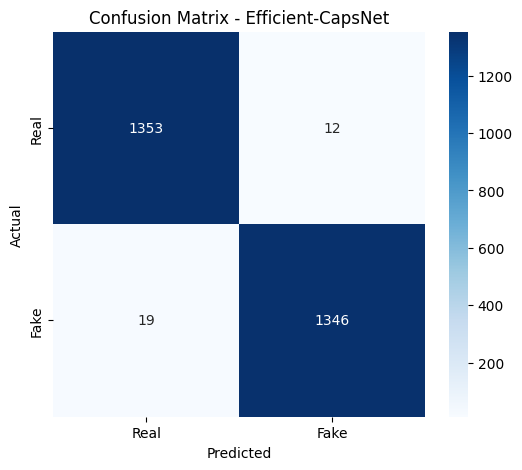

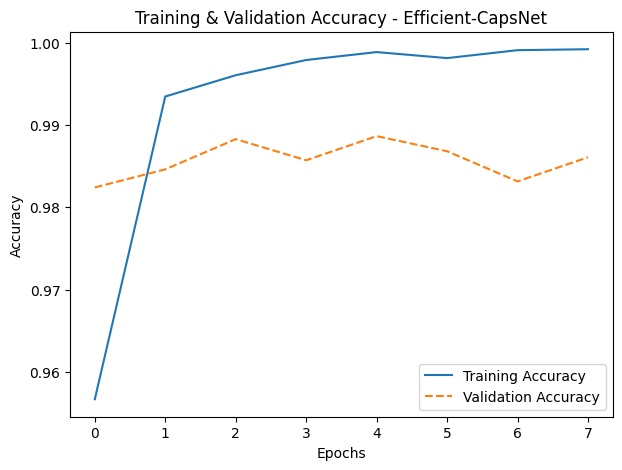


Training GRU_CNN...
Epoch 1/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9948 - loss: 0.0198

812/812 ━━━━━━━━━━━━━━━━━━━━ 217s 268ms/step - accuracy: 0.9948 - loss: 0.0198 - val_accuracy: 0.9868 - val_loss: 0.0462
Epoch 2/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9963 - loss: 0.0115

812/812 ━━━━━━━━━━━━━━━━━━━━ 257s 262ms/step - accuracy: 0.9963 - loss: 0.0115 - val_accuracy: 0.9868 - val_loss: 0.0442
Epoch 3/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 263s 264ms/step - accuracy: 0.9980 - loss: 0.0060 - val_accuracy: 0.9879 - val_loss: 0.0648
Epoch 4/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 217s 267ms/step - accuracy: 0.9984 - loss: 0.0056 - val_accuracy: 0.9875 - val_loss: 0.0716
Epoch 5/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 261s 265ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9868 - val_loss: 0.0565
Finished training GRU_CNN.


Evaluation of GRU_CNN:

86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step
Accuracy: 0.9868
Precision: 0.9868
Recall: 0.9868
F1-Score: 0.9868
AUC-ROC: 0.9985
Confusion Matrix:
[[1347   18]
 [  18 1347]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1365
           1       0.99      0.99      0.99      1365

    accuracy                           0.99      2730
   macro avg       0.

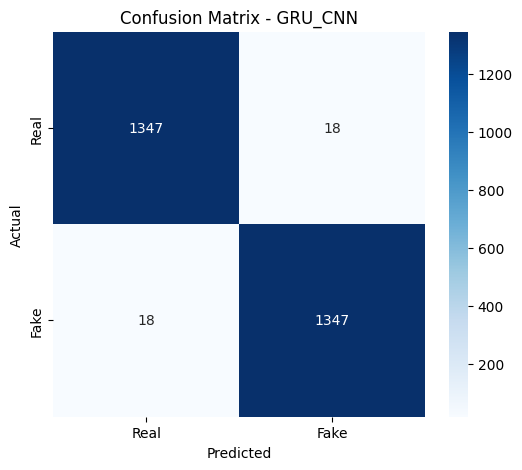

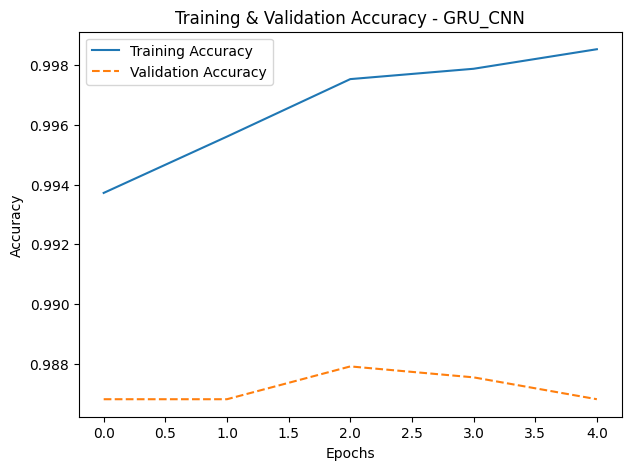


Training Attention-based BiLSTM...
Epoch 1/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.8764 - loss: 0.3388

812/812 ━━━━━━━━━━━━━━━━━━━━ 822s 991ms/step - accuracy: 0.8765 - loss: 0.3386 - val_accuracy: 0.9766 - val_loss: 0.1052
Epoch 2/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.9815 - loss: 0.0849

812/812 ━━━━━━━━━━━━━━━━━━━━ 856s 984ms/step - accuracy: 0.9815 - loss: 0.0849 - val_accuracy: 0.9821 - val_loss: 0.0827
Epoch 3/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 802s 984ms/step - accuracy: 0.9911 - loss: 0.0496 - val_accuracy: 0.9817 - val_loss: 0.0829
Epoch 4/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.9939 - loss: 0.0379

812/812 ━━━━━━━━━━━━━━━━━━━━ 800s 982ms/step - accuracy: 0.9939 - loss: 0.0379 - val_accuracy: 0.9864 - val_loss: 0.0677
Epoch 5/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 794s 972ms/step - accuracy: 0.9956 - loss: 0.0297 - val_accuracy: 0.9846 - val_loss: 0.0731
Epoch 6/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.9971 - loss: 0.0220

812/812 ━━━━━━━━━━━━━━━━━━━━ 806s 977ms/step - accuracy: 0.9971 - loss: 0.0220 - val_accuracy: 0.9842 - val_loss: 0.0655
Epoch 7/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 789s 972ms/step - accuracy: 0.9961 - loss: 0.0234 - val_accuracy: 0.9861 - val_loss: 0.0695
Epoch 8/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 802s 972ms/step - accuracy: 0.9986 - loss: 0.0131 - val_accuracy: 0.9861 - val_loss: 0.0699
Epoch 9/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 801s 970ms/step - accuracy: 0.9988 - loss: 0.0110 - val_accuracy: 0.9853 - val_loss: 0.0820
Finished training Attention-based BiLSTM.


Evaluation of Attention-based BiLSTM:

86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step
Accuracy: 0.9842
Precision: 0.9889
Recall: 0.9795
F1-Score: 0.9842
AUC-ROC: 0.9974
Confusion Matrix:
[[1350   15]
 [  28 1337]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1365
           1       0.99      0.98      0.98      1365

    accuracy                           0.98

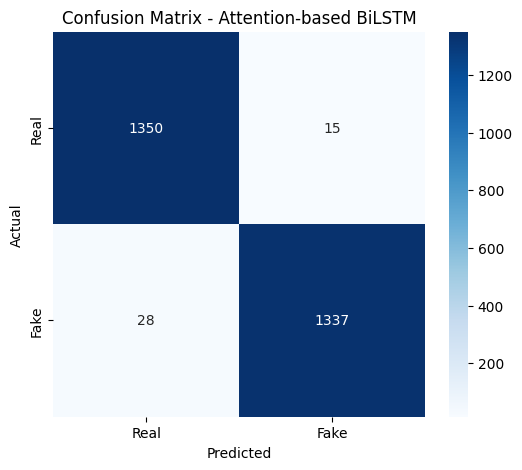

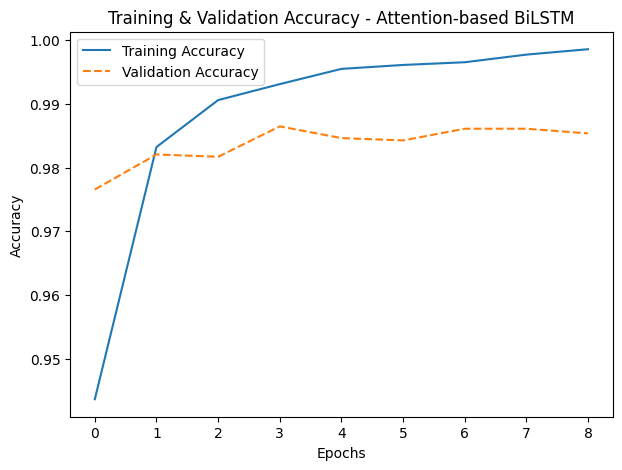

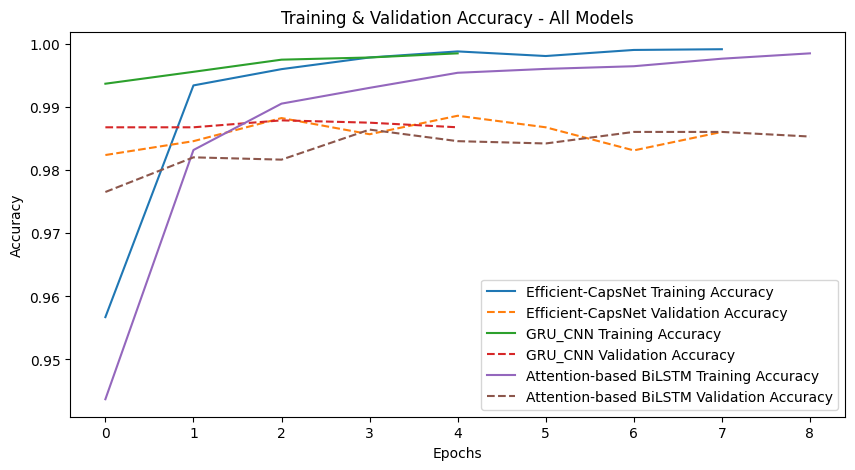

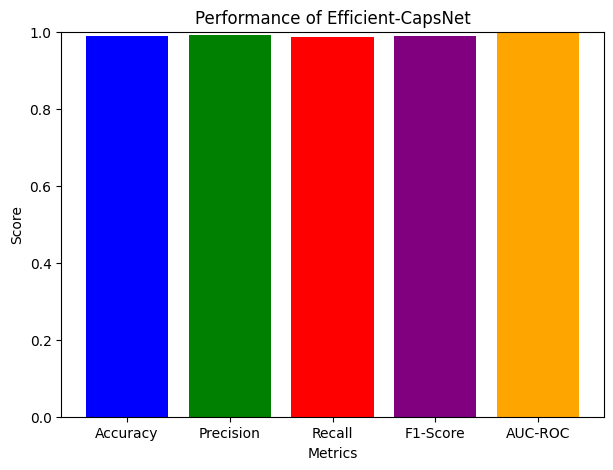

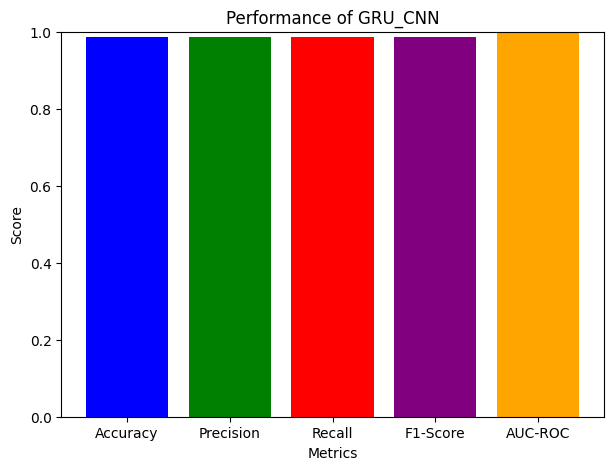

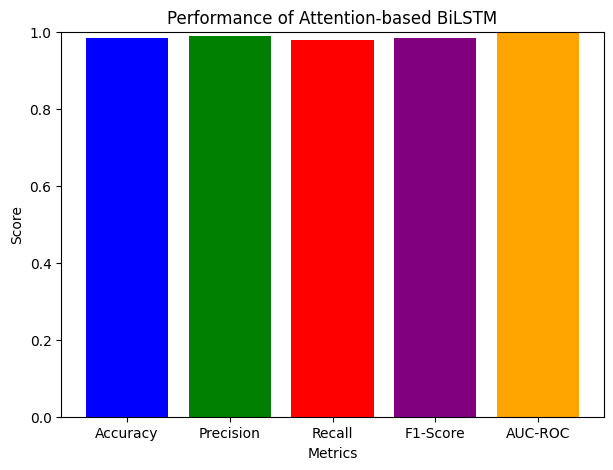

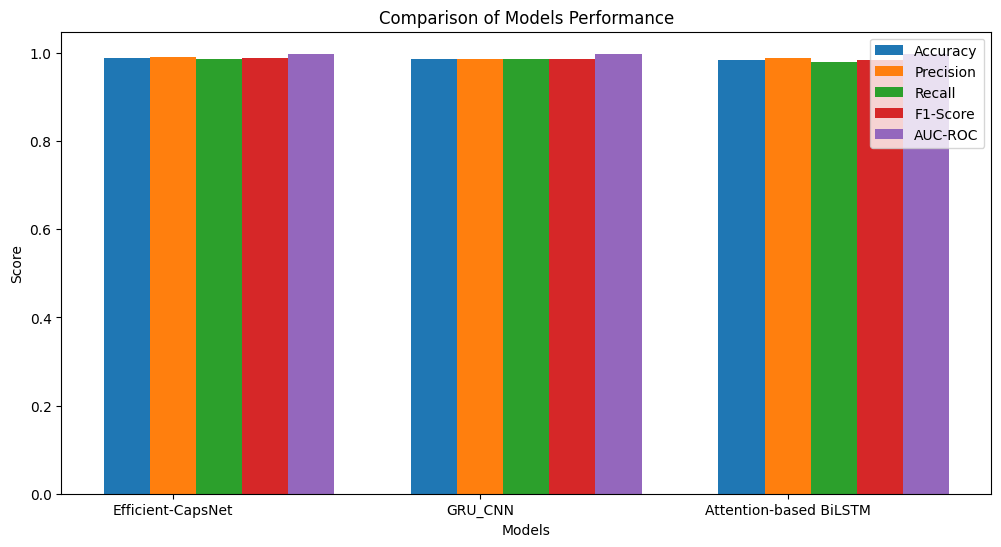

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten
from tensorflow.keras.models import Model

models = {
    "Efficient-CapsNet": build_efficient_capsnet(),
    "GRU_CNN": gru_cnn,
    "Attention-based BiLSTM": build_rnn_model()
}

histories = {}
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    # Save best model during training
    checkpoint = ModelCheckpoint(f"/content/drive/MyDrive/deepfake_text_models/{model_name}.h5", monitor="val_loss", save_best_only=True)

    # Train model
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_test_pad, y_test),
        epochs=10,  # Adjust as needed
        batch_size=32,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True), checkpoint]
    )

    print(f"Finished training {model_name}.\n")

    # Store training history
    histories[model_name] = history

    # Evaluate the model
    print(f"\nEvaluation of {model_name}:\n")
    y_pred = model.predict(X_test_pad)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    accuracy = accuracy_score(y_test_classes, y_pred_classes)
    precision = precision_score(y_test_classes, y_pred_classes, zero_division=1)
    recall = recall_score(y_test_classes, y_pred_classes, zero_division=1)
    f1 = f1_score(y_test_classes, y_pred_classes, zero_division=1)
    auc_roc = roc_auc_score(y_test_classes, y_pred[:, 1]) if y_pred.shape[1] > 1 else 0.0

    cm = confusion_matrix(y_test_classes, y_pred_classes)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test_classes, y_pred_classes))

    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }

    # ✅ Plot Confusion Matrix as Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # ✅ Plot Training & Validation Accuracy
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Training & Validation Accuracy - {model_name}')
    plt.legend()
    plt.show()

# ✅ Compare Training Accuracy for All Models
plt.figure(figsize=(10, 5))
for model_name, history in histories.items():
    plt.plot(history.history['accuracy'], label=f'{model_name} Training Accuracy')
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{model_name} Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy - All Models")
plt.legend()
plt.show()

# ✅ Individual Model Performance Bar Charts
for model_name, metrics in results.items():
    plt.figure(figsize=(7, 5))
    plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'red', 'purple', 'orange'])
    plt.ylim(0, 1)  # Scores are between 0 and 1
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.title(f"Performance of {model_name}")
    plt.show()

# ✅ Combined Model Performance Comparison
models_list = list(results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = np.array([list(results[model].values()) for model in models_list])

plt.figure(figsize=(12, 6))
width = 0.15  # Width of each bar

for i, metric in enumerate(metrics):
    plt.bar(np.arange(len(models_list)) + width * i, values[:, i], width=width, label=metric)

plt.xticks(np.arange(len(models_list)) + width, models_list)
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Models Performance')
plt.legend()
plt.show()
